In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('insurance.csv')


In [3]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

In [4]:
data.head()
data.info()

data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

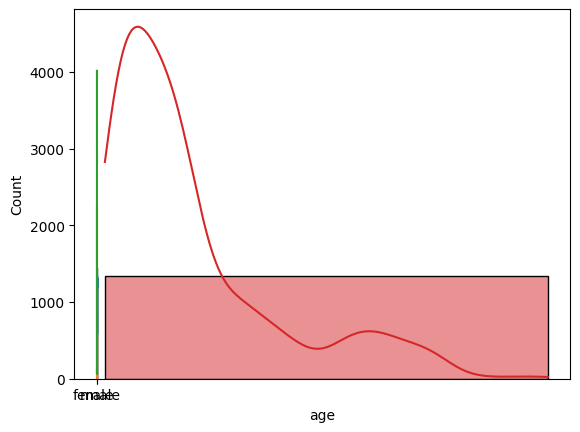

In [6]:
numeric_columns = ['age', 'sex', 'children', 'charges']
for col in numeric_columns:
    plt.Figure(figsize=(6,4))
    sns.histplot(data[col] ,kde= 20, bins = True)

<Axes: xlabel='count', ylabel='sex'>

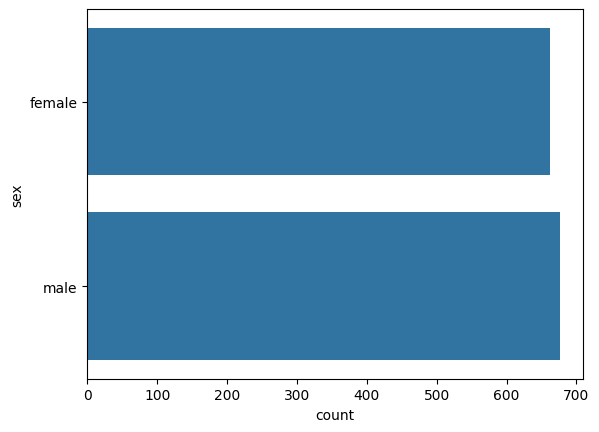

In [7]:
sns.countplot(data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

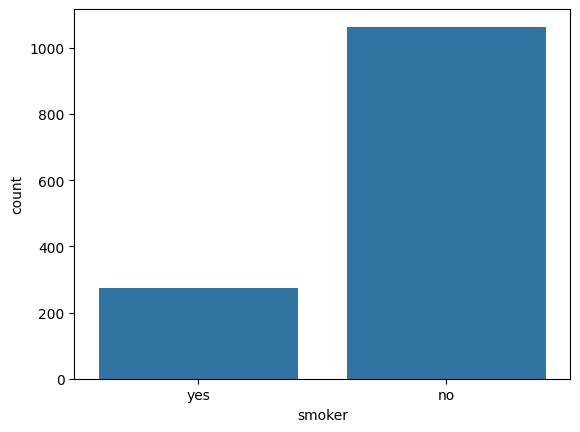

In [8]:
sns.countplot( x=data['smoker'])

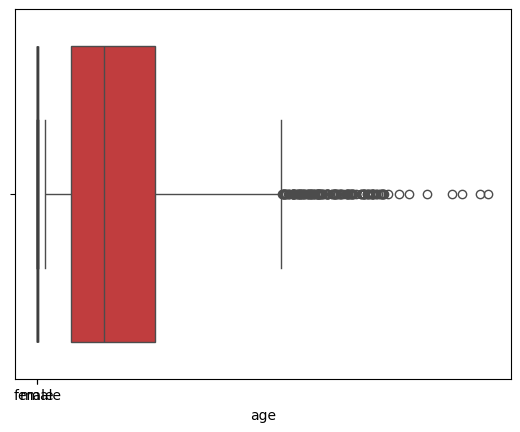

In [9]:
for col in numeric_columns:
    plt.Figure(figsize=(6,4))
    sns.boxplot( x =data[col])

<Axes: >

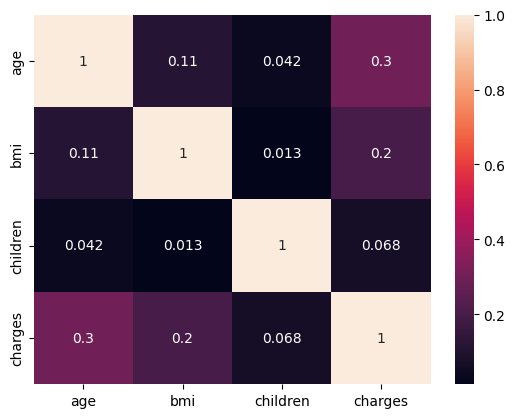

In [10]:
plt.Figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),annot=True)

DATA CLEANING ANS PROCESISING


In [11]:
df_copy = data.copy()


In [12]:
df_copy.shape

(1338, 7)

In [13]:
df_copy.drop_duplicates(inplace=True)

In [14]:
df_copy.shape

(1337, 7)

In [15]:
df_copy.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [16]:
df_copy['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

LABEL INCODING


In [17]:
df_copy['sex'] = df_copy['sex'].map({"male": 1, "female:":0})

In [18]:
df_copy.head()

,age,sex,bmi,children,smoker,region,charges
0,19,NaN,27.900,0,yes,southwest,16884.92400
1,18,1.0,33.770,1,no,southeast,1725.55230
2,28,1.0,33.000,3,no,southeast,4449.46200
3,33,1.0,22.705,0,no,northwest,21984.47061
4,32,1.0,28.880,0,no,northwest,3866.85520


In [19]:
df_copy['smoker'] = df_copy['smoker'].map({"no": 0, "yes":1})

In [20]:
df_copy

,age,sex,bmi,children,smoker,region,charges
0,19,NaN,27.900,0,1,southwest,16884.92400
1,18,1.0,33.770,1,0,southeast,1725.55230
2,28,1.0,33.000,3,0,southeast,4449.46200
3,33,1.0,22.705,0,0,northwest,21984.47061
4,32,1.0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0,northwest,10600.54830
1334,18,NaN,31.920,0,0,northeast,2205.98080
1335,18,NaN,36.850,0,0,southeast,1629.83350
1336,21,NaN,25.800,0,0,southwest,2007.94500


In [21]:
df_copy.rename(columns={
    'sex' : 'is_female',
    'smoker': 'is_smoker'
},inplace=True)

In [22]:
df_copy

,age,is_female,bmi,children,is_smoker,region,charges
0,19,NaN,27.900,0,1,southwest,16884.92400
1,18,1.0,33.770,1,0,southeast,1725.55230
2,28,1.0,33.000,3,0,southeast,4449.46200
3,33,1.0,22.705,0,0,northwest,21984.47061
4,32,1.0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0,northwest,10600.54830
1334,18,NaN,31.920,0,0,northeast,2205.98080
1335,18,NaN,36.850,0,0,southeast,1629.83350
1336,21,NaN,25.800,0,0,southwest,2007.94500


In [23]:
df_copy = pd.get_dummies(df_copy,columns = ['region'],drop_first=True)

In [24]:
df_copy

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,NaN,27.900,0,1,16884.92400,False,False,True
1,18,1.0,33.770,1,0,1725.55230,False,True,False
2,28,1.0,33.000,3,0,4449.46200,False,True,False
3,33,1.0,22.705,0,0,21984.47061,True,False,False
4,32,1.0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0,10600.54830,True,False,False
1334,18,NaN,31.920,0,0,2205.98080,False,False,False
1335,18,NaN,36.850,0,0,1629.83350,False,True,False
1336,21,NaN,25.800,0,0,2007.94500,False,False,True


In [29]:
df_copy

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,NaN,27.900,0,1,16884.92400,False,False,True
1,18,1.0,33.770,1,0,1725.55230,False,True,False
2,28,1.0,33.000,3,0,4449.46200,False,True,False
3,33,1.0,22.705,0,0,21984.47061,True,False,False
4,32,1.0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0,10600.54830,True,False,False
1334,18,NaN,31.920,0,0,2205.98080,False,False,False
1335,18,NaN,36.850,0,0,1629.83350,False,True,False
1336,21,NaN,25.800,0,0,2007.94500,False,False,True


FEATURE INGEENERING AND EXTRACTION

In [31]:
df_copy = df_copy.astype(float)

In [32]:
df_copy

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19.0,NaN,27.900,0.0,1.0,16884.92400,0.0,0.0,1.0
1,18.0,1.0,33.770,1.0,0.0,1725.55230,0.0,1.0,0.0
2,28.0,1.0,33.000,3.0,0.0,4449.46200,0.0,1.0,0.0
3,33.0,1.0,22.705,0.0,0.0,21984.47061,1.0,0.0,0.0
4,32.0,1.0,28.880,0.0,0.0,3866.85520,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1333,50.0,1.0,30.970,3.0,0.0,10600.54830,1.0,0.0,0.0
1334,18.0,NaN,31.920,0.0,0.0,2205.98080,0.0,0.0,0.0
1335,18.0,NaN,36.850,0.0,0.0,1629.83350,0.0,1.0,0.0
1336,21.0,NaN,25.800,0.0,0.0,2007.94500,0.0,0.0,1.0


<Axes: xlabel='bmi', ylabel='Count'>

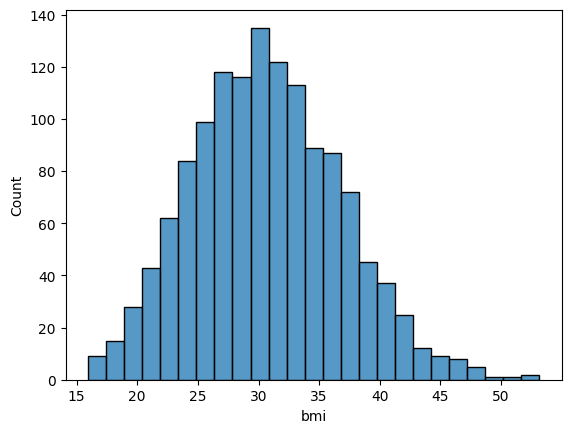

In [33]:
sns.histplot(df_copy['bmi'])

In [34]:
df_copy['bmi_cateogary'] = pd.cut(
    df_copy['bmi'],
    bins= [0,18.5,24.9,29.4,float('inf')],
    labels= ['underweight','normal','overweight','obes']
)

In [35]:
df_copy

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cateogary
0,19.0,NaN,27.900,0.0,1.0,16884.92400,0.0,0.0,1.0,overweight
1,18.0,1.0,33.770,1.0,0.0,1725.55230,0.0,1.0,0.0,obes
2,28.0,1.0,33.000,3.0,0.0,4449.46200,0.0,1.0,0.0,obes
3,33.0,1.0,22.705,0.0,0.0,21984.47061,1.0,0.0,0.0,normal
4,32.0,1.0,28.880,0.0,0.0,3866.85520,1.0,0.0,0.0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50.0,1.0,30.970,3.0,0.0,10600.54830,1.0,0.0,0.0,obes
1334,18.0,NaN,31.920,0.0,0.0,2205.98080,0.0,0.0,0.0,obes
1335,18.0,NaN,36.850,0.0,0.0,1629.83350,0.0,1.0,0.0,obes
1336,21.0,NaN,25.800,0.0,0.0,2007.94500,0.0,0.0,1.0,overweight
